### Group Prject - London Bike Rentals

In this project, you will work with the London Bikes dataset, which records daily bike rentals in the city along with key variables such as dates, weather conditions, and seasonality.

The goal is to apply the full data analytics workflow:

- Clean and prepare the dataset.

- Explore the data through visualisation.

- Construct and interpret confidence intervals.

- Build a regression model to explain variation in bike rentals.

- By the end, you will connect statistical concepts with practical Python analysis.

In [4]:
## Import libraries and data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

bikes = pd.read_csv("../Data/london_bikes.csv")

bikes.head()

print(bikes.shape)
print(bikes.columns)
print(bikes.dtypes)

(4934, 17)
Index(['date', 'bikes_hired', 'year', 'wday', 'month', 'week', 'cloud_cover',
       'humidity', 'pressure', 'radiation', 'precipitation', 'snow_depth',
       'sunshine', 'mean_temp', 'min_temp', 'max_temp', 'weekend'],
      dtype='str')
date                 str
bikes_hired        int64
year               int64
wday                 str
month                str
week               int64
cloud_cover      float64
humidity         float64
pressure         float64
radiation        float64
precipitation    float64
snow_depth       float64
sunshine         float64
mean_temp        float64
min_temp         float64
max_temp         float64
weekend             bool
dtype: object


**1. Data Cleaning**

Check for missing values across columns. How would you handle them?

Inspect the date column and ensure it is correctly formatted as datetime. Extract useful features (year, month, day, day of week, season).

Convert categorical variables (e.g., season, weather) to appropriate categories in Python.

Ensure numeric columns (e.g., bikes rented, temperature) are in the right format.

In [5]:
## Your code goes here
# Check missing values
bikes.isna().sum()

# Create missing value summary
missing_summary = pd.DataFrame({
    "missing_count": bikes.isna().sum(),
    "missing_percent": bikes.isna().mean() * 100
})

missing_summary

# Fill missing numerical values with the median
numeric_cols = [
    "cloud_cover",
    "humidity",
    "pressure",
    "radiation",
    "precipitation",
    "snow_depth",
    "sunshine",
    "mean_temp",
    "min_temp",
    "max_temp"
]

for col in numeric_cols:
    bikes[col] = bikes[col].fillna(bikes[col].median())

# Check that missing values have been handled
bikes.isna().sum()

# Convert date to datetime
bikes["date"] = pd.to_datetime(bikes["date"])

# Extract date-related features
bikes["year"] = bikes["date"].dt.year
bikes["month"] = bikes["date"].dt.month
bikes["day"] = bikes["date"].dt.day
bikes["day_of_week"] = bikes["date"].dt.day_name()

# Create season variable
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

bikes["season"] = bikes["month"].apply(get_season)

# Convert categorical variables to category type
bikes["season"] = bikes["season"].astype("category")
bikes["day_of_week"] = bikes["day_of_week"].astype("category")
bikes["wday"] = bikes["wday"].astype("category")

# Check final data types
bikes.dtypes

date             datetime64[us, UTC]
bikes_hired                    int64
year                           int32
wday                        category
month                          int32
week                           int64
cloud_cover                  float64
humidity                     float64
pressure                     float64
radiation                    float64
precipitation                float64
snow_depth                   float64
sunshine                     float64
mean_temp                    float64
min_temp                     float64
max_temp                     float64
weekend                         bool
day                            int32
day_of_week                 category
season                      category
dtype: object

Missing values in numerical weather variables were filled using the median. The date column was converted to datetime, and year, month, day, day of week, and season were extracted. Categorical variables were converted to category type, while numerical variables were checked to ensure they had appropriate numeric formats.

**2. Exploratory Data Analysis (EDA)**

Plot the distribution of bikes rented.

Explore how rentals vary by season and month.

Investigate the relationship between temperature and bikes rented.

**Deliverables:**

At least 3 clear visualisations with captions.

A short written interpretation of key patterns (seasonality, weather effects, etc.).



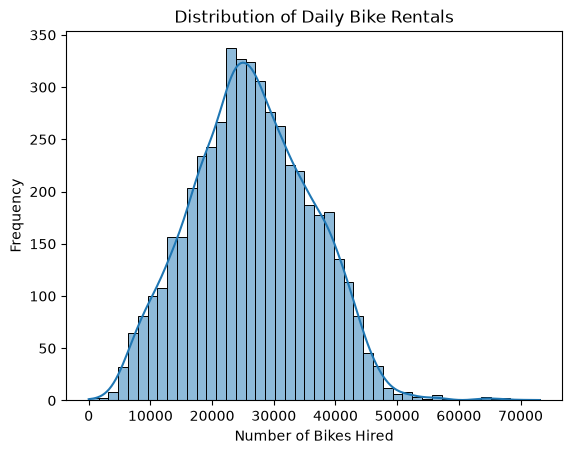

In [6]:
## Your code goes here
sns.histplot(
    data=bikes,
    x="bikes_hired",
    kde=True
)

plt.title("Distribution of Daily Bike Rentals")
plt.xlabel("Number of Bikes Hired")
plt.ylabel("Frequency")

plt.show()

Figure 1. Distribution of daily bike rentals in London.
Daily bike rentals are concentrated around 20,000 to 35,000 hires, with fewer days showing very low or very high demand. The distribution is slightly right-skewed, suggesting that a small number of days experienced unusually high rental demand.

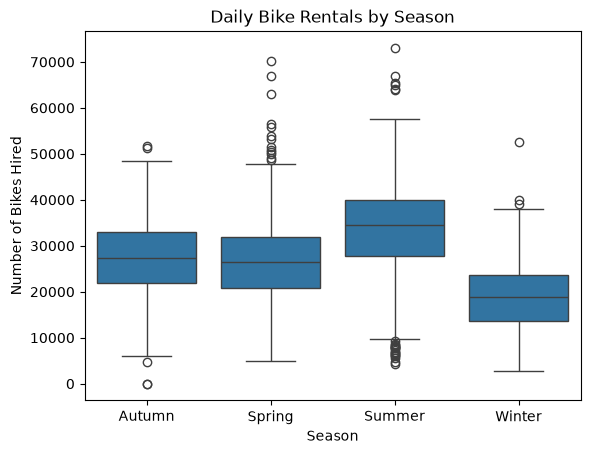

In [10]:
sns.boxplot(
    data=bikes,
    x="season",
    y="bikes_hired"
)

plt.title("Daily Bike Rentals by Season")
plt.xlabel("Season")
plt.ylabel("Number of Bikes Hired")

plt.show()

Figure 2. Distribution of daily bike rentals across seasons.
Bike rental demand varies clearly by season. Summer has the highest median number of rentals, while winter has the lowest, suggesting strong seasonality in bike usage. Spring and autumn show intermediate levels of demand. Summer also shows a wider spread in rentals, indicating greater variability in daily demand.

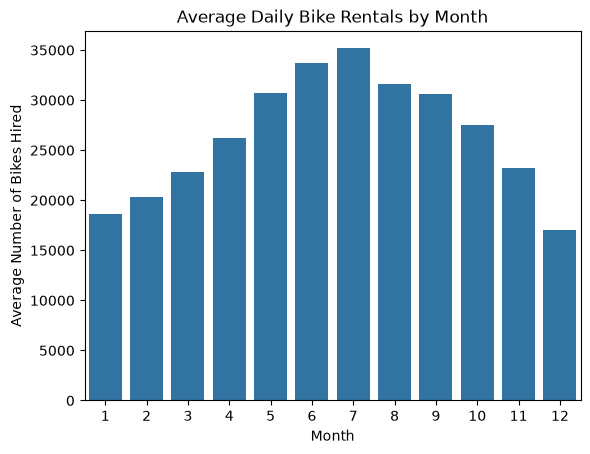

In [7]:
monthly_rentals = (
    bikes.groupby("month")["bikes_hired"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=monthly_rentals,
    x="month",
    y="bikes_hired"
)

plt.title("Average Daily Bike Rentals by Month")
plt.xlabel("Month")
plt.ylabel("Average Number of Bikes Hired")

plt.show()

Figure 3. Average daily bike rentals by month.
Average bike rentals increase from winter into spring and summer, reaching the highest level in July. After summer, demand gradually declines, with the lowest average rentals occurring in December. This shows a clear seasonal pattern in bike usage.

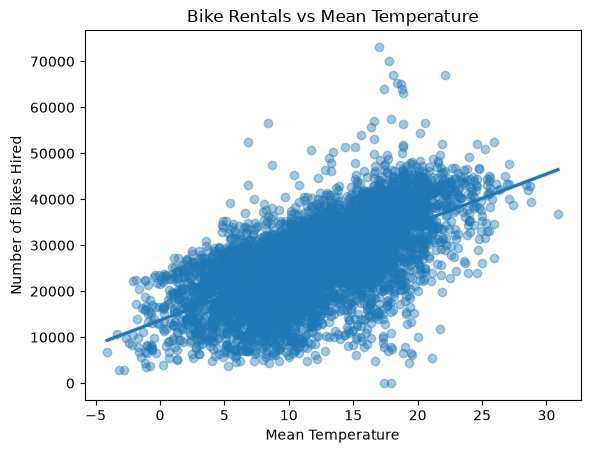

In [8]:
sns.regplot(
    data=bikes,
    x="mean_temp",
    y="bikes_hired",
    scatter_kws={"alpha": 0.4}
)

plt.title("Bike Rentals vs Mean Temperature")
plt.xlabel("Mean Temperature")
plt.ylabel("Number of Bikes Hired")

plt.show()

Figure 4. Relationship between mean temperature and daily bike rentals.
There is a clear positive relationship between mean temperature and daily bike rentals. Warmer days tend to have higher bike rental demand, although the wide spread of observations suggests that temperature is not the only factor affecting rentals. Temperature matters, but other variables probably matter too.

**3. Construct 95% confidence intervals for the mean number of bikes rented per season.**

Repeat the calculation per month.

Interpret the result:

What range of values do you expect the true mean to lie in?

Which seasons/months have higher or lower average demand?

Are there overlaps in the intervals, and what does that mean?

**Deliverables:**

A table or plot showing the mean and confidence intervals.

A short interpretation.

In [9]:
## Your code goes here
!pip install scipy

from scipy import stats


season_ci = (
    bikes.groupby("season")["bikes_hired"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

season_ci


season_ci["se"] = (
    season_ci["std"] / np.sqrt(season_ci["count"])
)


season_ci["lower_ci"] = (
    season_ci["mean"] - 1.96 * season_ci["se"]
)

season_ci["upper_ci"] = (
    season_ci["mean"] + 1.96 * season_ci["se"]
)

season_ci



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


,season,mean,std,count,se,lower_ci,upper_ci
0,Autumn,27136.845369,7857.506100,1274,220.140533,26705.369925,27568.320813
1,Spring,26609.178930,8660.272182,1196,250.418236,26118.359187,27099.998672
2,Summer,33455.454841,9147.748858,1229,260.938578,32944.015228,33966.894454
3,Winter,18610.162753,6625.762758,1235,188.539522,18240.625289,18979.700217


Summer has the highest average daily bike rental demand, with a mean of about 33,455 rentals, while winter has the lowest average demand at about 18,610. The confidence intervals for summer and winter are clearly separated from the other seasons, suggesting substantial seasonal differences in average demand. The confidence intervals for spring and autumn overlap, indicating that their average rental levels are more similar.

In [10]:
month_ci = (
    bikes.groupby("month")["bikes_hired"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# Standard error
month_ci["se"] = (
    month_ci["std"] / np.sqrt(month_ci["count"])
)

# 95% confidence interval
month_ci["lower_ci"] = (
    month_ci["mean"] - 1.96 * month_ci["se"]
)

month_ci["upper_ci"] = (
    month_ci["mean"] + 1.96 * month_ci["se"]
)

# Sort months from January to December
month_ci = (
    month_ci
    .sort_values("month")
    .reset_index(drop=True)
)

month_ci.round(2)

,month,mean,std,count,se,lower_ci,upper_ci
0,1,18652.47,5992.56,434,287.65,18088.67,19216.27
1,2,20370.17,6528.79,367,340.80,19702.21,21038.14
2,3,22851.46,7739.31,403,385.52,22095.83,23607.08
3,4,26242.04,7775.30,390,393.72,25470.35,27013.72
4,5,30722.20,8561.91,403,426.50,29886.26,31558.14
5,6,33744.10,8765.34,390,443.85,32874.16,34614.05
6,7,35160.68,8371.38,405,415.98,34345.36,35975.99
7,8,31604.79,9832.83,434,471.99,30679.69,32529.89
8,9,30647.84,8260.43,420,403.07,29857.83,31437.85
9,10,27510.83,6897.00,434,331.07,26861.94,28159.72


Monthly bike rental demand also shows a clear seasonal pattern. July has the highest average daily demand at about 35,161 rentals, while December has the lowest at about 17,080. Demand generally increases from winter into summer and then declines toward the end of the year. Some confidence intervals overlap, particularly for months with similar average demand, such as May and September, suggesting that their true mean rental levels may be relatively similar. The overlapping intervals suggest that the mean demand levels may be similar.

**Regression Analysis**

What variables influence the number of bikes rented (y) and how? Build a regression model that best explains the variability in bikes rented.

**Interpret:**

Which predictors are significant?

What do the coefficients mean (in practical terms)?

How much of the variation in bike rentals is explained (R²)?

**Deliverables:**

Regression output table.

A short discussion of which factors matter most for predicting bike rentals.

In [15]:
### Your code goes here
bikes["weekend_int"] = bikes["weekend"].astype(int)


bikes["year_centered"] = bikes["year"] - bikes["year"].min()

bikes[[
    "bikes_hired",
    "mean_temp",
    "precipitation",
    "sunshine",
    "humidity",
    "weekend_int",
    "year_centered",
    "season"
]].head()


import statsmodels.formula.api as smf


model = smf.ols(
    formula="""
    bikes_hired ~
    mean_temp +
    precipitation +
    sunshine +
    humidity +
    weekend_int +
    year_centered +
    C(season)
    """,
    data=bikes
).fit()

print(model.summary())


regression_table = pd.DataFrame({
    "Coefficient": model.params,
    "Std_Error": model.bse,
    "P_Value": model.pvalues,
    "CI_Lower": model.conf_int()[0],
    "CI_Upper": model.conf_int()[1]
})

regression_table = regression_table.reset_index()

regression_table = regression_table.rename(
    columns={"index": "Predictor"}
)

regression_table["Significant"] = np.where(
    regression_table["P_Value"] < 0.05,
    "Yes",
    "No"
)

regression_table = regression_table.round(3)

regression_table

                            OLS Regression Results                            
Dep. Variable:            bikes_hired   R-squared:                       0.614
Model:                            OLS   Adj. R-squared:                  0.613
Method:                 Least Squares   F-statistic:                     869.3
Date:                Sun, 20 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:35:26   Log-Likelihood:                -49936.
No. Observations:                4934   AIC:                         9.989e+04
Df Residuals:                    4924   BIC:                         9.996e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            2.485e+04   1

,Predictor,Coefficient,Std_Error,P_Value,CI_Lower,CI_Upper,Significant
0,Intercept,24851.469,1230.089,0.000,22439.946,27262.992,Yes
1,C(season)[T.Spring],-2029.461,267.886,0.000,-2554.637,-1504.286,Yes
2,C(season)[T.Summer],-240.965,287.462,0.402,-804.519,322.589,No
3,C(season)[T.Winter],-3660.939,286.428,0.000,-4222.466,-3099.412,Yes
4,mean_temp,630.254,24.566,0.000,582.093,678.415,Yes
5,precipitation,-36.802,2.399,0.000,-41.506,-32.098,Yes
6,sunshine,52.170,3.337,0.000,45.629,58.711,Yes
7,humidity,-114.009,13.180,0.000,-139.848,-88.170,Yes
8,weekend_int,-4311.629,189.731,0.000,-4683.587,-3939.671,Yes
9,year_centered,560.315,22.019,0.000,517.148,603.481,Yes


The regression model explains approximately 61.4% of the variation in daily bike rentals (R² = 0.614), and the overall model is statistically significant (p < 0.001). Mean temperature, sunshine and year are positively associated with bike rentals, while precipitation, humidity and weekends are negatively associated with demand. Holding other variables constant, a 1°C increase in mean temperature is associated with approximately 630 additional daily rentals, while weekends are associated with around 4,312 fewer rentals than weekdays. Most predictors are statistically significant at the 5% level, although summer is not significantly different from autumn after controlling for weather and other factors.

## Deliverables
A knitted HTML, one person per group to submit